<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/ECG_Video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
# INSTALAR BIBLIOTECA
!pip install wfdb -q

In [115]:
# DESCARGAR DATOS ECG DE PHYSIONET

!mkdir -p ecg-data

!wget -q https://physionet.org/files/ltafdb/1.0.0/23.dat -P ecg-data/
!wget -q https://physionet.org/files/ltafdb/1.0.0/23.hea -P ecg-data/
!wget -q https://physionet.org/files/ltafdb/1.0.0/23.atr -P ecg-data/

^C


In [116]:
# IMPORTAR BIBLIOTECAS

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [117]:
# CARGAR LA SEÑAL ECG

record_path = 'ecg-data/23'

In [118]:
#wfdb. rdann ( record_name , extension , sampfrom = 0 , sampto = None ,
#shift_samps = False , pn_dir = None , return_label_elements = ['symbol'] , summarize_labels = False )

#extension str
#The annotatator extension of the annotation file. ie. for file ‘100.atr’, extension=’atr’.

ann = wfdb.rdann(record_path, 'atr')

In [119]:
#wfdb.rdrecord(record_name, sampfrom=0, sampto=None, channels=None, physical=True,
#pn_dir=None, m2s=True, smooth_frames=True, ignore_skew=False, return_res=64,
#force_channels=True, channel_names=None, warn_empty=False)

#Read a WFDB record and return the signal and record descriptors as attributes in a
#Record or MultiRecord object.

record = wfdb.rdrecord('ecg-data/23')

In [120]:
#Frecuencia de muestreo

record.fs

128

In [121]:
#Canales con señal ECG

record.sig_name

['ECG', 'ECG']

In [122]:
#Señal de ECG del canal 0

signal=record.p_signal[:,0]

In [123]:
signal

array([-0.06916005, -0.06422005, -0.07904006, ...,  0.00494   ,
        0.00988001, -0.02964002])

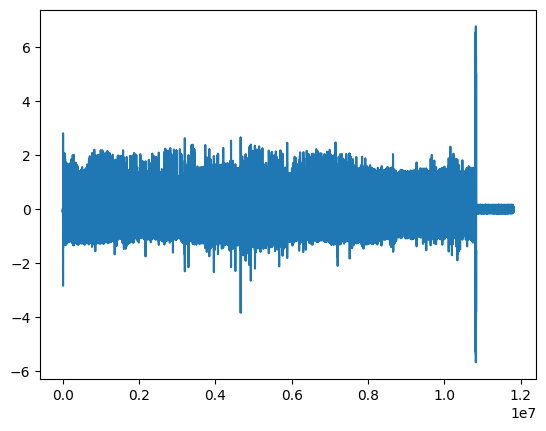

In [127]:
plt.plot(signal)
plt.show()

In [128]:
#Tamaño de la señal
len(signal)

11819520

In [129]:
#Tiempo en Segundos

len(signal)/record.fs

92340.0

In [130]:
#Tiempo en Horas

((len(signal)/record.fs)/60)/60

25.65

In [131]:
#The rdsamp function exists as a simple alternative to rdrecord for the common
#purpose of extracting the physical signals and a few important descriptor fields.

#wfdb.rdsamp(record_name, sampfrom=0, sampto=None, channels=None, pn_dir=None, channel_names=None,
#warn_empty=False, return_res=64)

#Read a WFDB record, and return the physical signals and a few important descriptor fields.

signals, fields = wfdb.rdsamp(record_path)

In [132]:
fields

{'fs': 128,
 'sig_len': 11819520,
 'n_sig': 2,
 'base_date': datetime.date(2003, 7, 18),
 'base_time': datetime.time(18, 18, 33),
 'units': ['mV', 'mV'],
 'sig_name': ['ECG', 'ECG'],
 'comments': []}

In [133]:
signals

array([[-0.06916005, -0.06422005],
       [-0.06422005, -0.06916005],
       [-0.07904006, -0.05928004],
       ...,
       [ 0.00494   ,  0.03458003],
       [ 0.00988001,  0.04446003],
       [-0.02964002, -0.00494   ]])

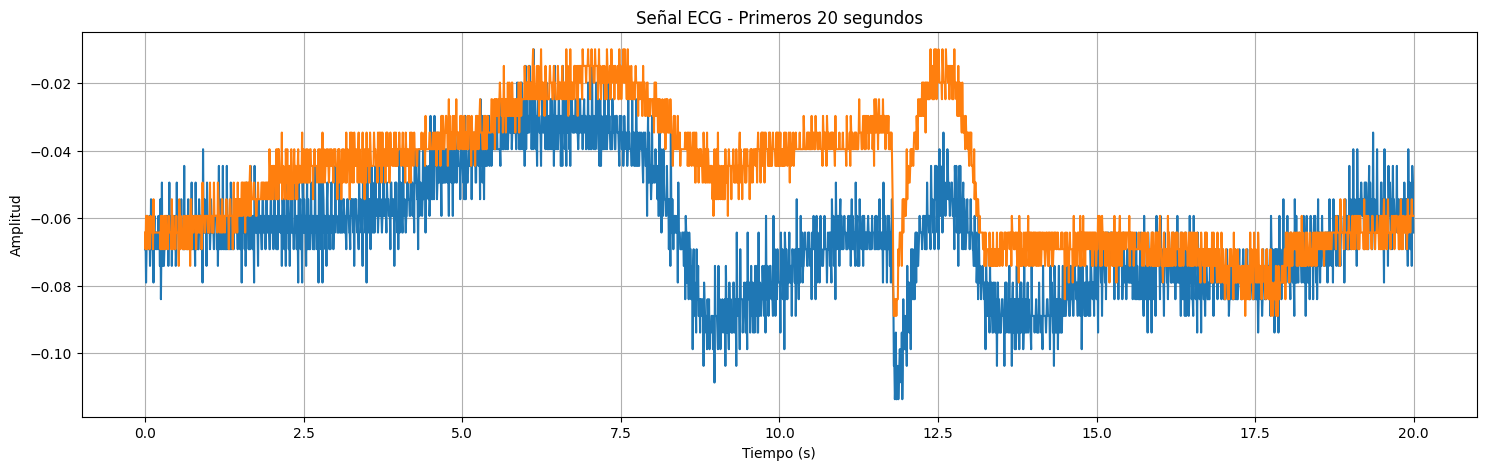

In [134]:
# GRAFICAR ECG COMPLETO (PRIMEROS 20 SEGUNDOS)

time=np.arange(len(signal))/record.fs

plt.figure(figsize=(18,5))

seconds_to_show = 20
samples = int(seconds_to_show * fs)

plt.plot(time[:samples], signals[:samples])

plt.title("Señal ECG - Primeros 20 segundos")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)

plt.show()

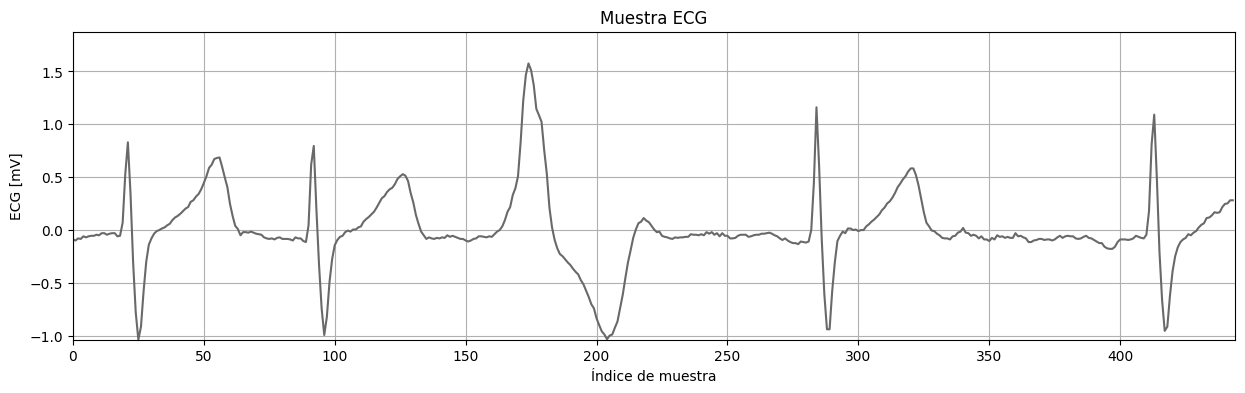

In [135]:
# Muestra representativa de la señal bruta...
start = 7190174
end = 7190618
time_part = time[start: end]
signal_part  = signals[start: end, 0]

plt.figure(figsize=[15, 4])
plt.plot(signal_part, color='dimgray')

plt.grid()
plt.xlabel('Índice de muestra')
plt.ylabel('ECG [mV]')
plt.title('Muestra ECG')
plt.xlim(0, len(signal_part))
plt.ylim(signal_part.min(), signal_part.max() + 0.3)
plt.show()

In [136]:
# `symbol` es la clase de etiqueta, `sample` es el índice para el array de señales.
df = pd.DataFrame({'symbol': ann.symbol, 'aux': ann.aux_note, 'position': ann.sample})
df.head()

,symbol,aux,position
0,+,(N,8379
1,V,,8399
2,N,,8509
3,A,,8584
4,N,,8716


In [137]:
wfdb.io.show_ann_labels()

    label_store symbol                                    description
0             0                              Not an actual annotation
1             1      N                                    Normal beat
2             2      L                  Left bundle branch block beat
3             3      R                 Right bundle branch block beat
4             4      a                Aberrated atrial premature beat
5             5      V              Premature ventricular contraction
6             6      F          Fusion of ventricular and normal beat
7             7      J              Nodal (junctional) premature beat
8             8      A                   Atrial premature contraction
9             9      S     Premature or ectopic supraventricular beat
10           10      E                        Ventricular escape beat
11           11      j                 Nodal (junctional) escape beat
12           12      /                                     Paced beat
13           13     

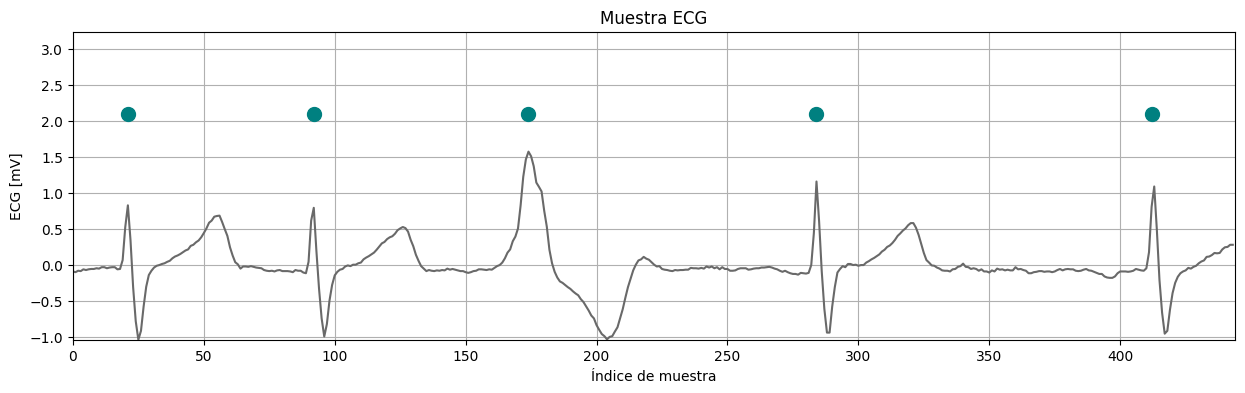

In [138]:
# Muestra representativa de la señal bruta...
start = 7190174
end = 7190618
signal_part  = signals[start: end, 0]

plt.figure(figsize=[15, 4])
plt.plot(signal_part, color='dimgray')

#... y las anotaciones correspondientes
ids = (df.position > start) & (df.position < end)
df_part = df[ids]

# Desplaza las posiciones de los pulsos de muestra para que coincidan con el fragmento de señal.
annotation_xs = df_part.position - start
annotation_ys = np.ones_like(annotation_xs) * 2.1
plt.plot(annotation_xs, annotation_ys, 'o', color='teal', ms=10)
plt.grid()
plt.xlabel('Índice de muestra')
plt.ylabel('ECG [mV]')
plt.title('Muestra ECG')
plt.xlim(0, len(signal_part))
plt.ylim(signal_part.min(), signal_part.max() + 1.666)
plt.show()

In [139]:
ids = (df.position > start) & (df.position < end)
df_part = df[ids]
df_part

,symbol,aux,position
73194,N,,7190195
73195,N,,7190266
73196,V,,7190348
73197,N,,7190458
73198,N,,7190586


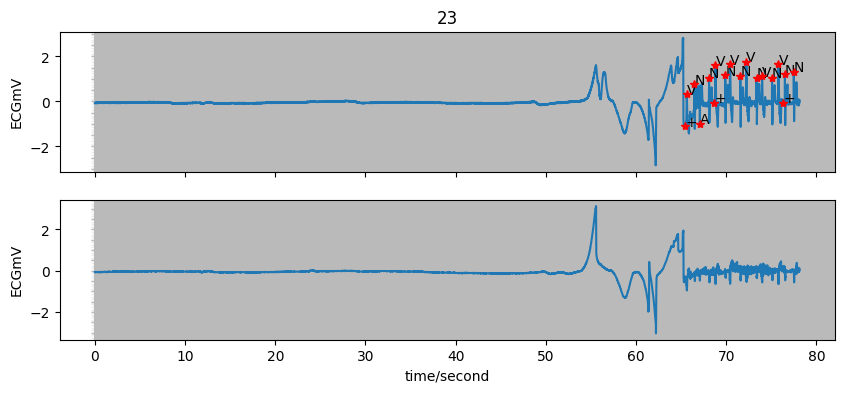

In [140]:
record1 = wfdb.rdrecord('ecg-data/23', sampto=10000)
annotation = wfdb.rdann('ecg-data/23', 'atr', sampto=10000)

wfdb.plot_wfdb(record=record1, annotation=annotation, plot_sym=True,
                   time_units='seconds', title='23',
                   figsize=(10,4), ecg_grids='all')

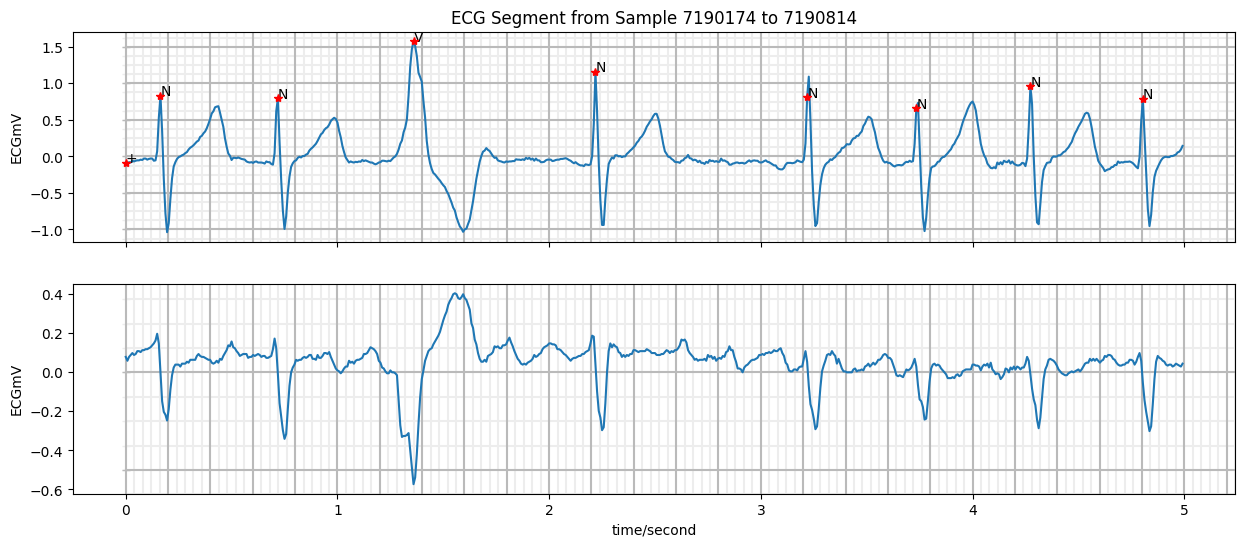

In [141]:
# Define the start sample and duration for the plot
start_sample = 7190174
duration_seconds = 5 # Plot 5 seconds of data around the start_sample

# Calculate end_sample based on duration and sampling frequency
fs = record.fs # Assuming fs is already defined from `record = wfdb.rdrecord('ecg-data/23')`
end_sample = start_sample + int(duration_seconds * fs)

# Load the record and annotation for the specified range
record_segment = wfdb.rdrecord(record_path, sampfrom=start_sample, sampto=end_sample)
annotation_segment = wfdb.rdann(record_path, 'atr', sampfrom=start_sample, sampto=end_sample, shift_samps=True)

# Plot the segment using wfdb.plot_wfdb
wfdb.plot_wfdb(
    record=record_segment,
    annotation=annotation_segment,
    plot_sym=True,
    time_units='seconds',
    title=f'ECG Segment from Sample {start_sample} to {end_sample}',
    figsize=(15, 6),
    ecg_grids='all'
)
plt.show()

In [142]:
import wfdb.processing
#wfdb.processing.ann2rr(record_name, extension, pn_dir=None, start_time=None, stop_time=None,
#format=None, as_array=True)

#Obtain RR interval series from ECG annotation files.

wfdb.processing.ann2rr(record_path, 'atr', as_array=True)

array([8379,   20,  110, ...,   93,  137,  140])

In [143]:
#wfdb.processing.calc_mean_hr(rr, fs=None, min_rr=None, max_rr=None, rr_units='samples')
#Compute mean heart rate in beats per minute, from a set of R-R intervals. Returns 0 if rr is empty.

rr_intervals = wfdb.processing.ann2rr(record_path, 'atr', as_array=True)
mean_hr = wfdb.processing.calc_mean_hr(rr_intervals, fs=record.fs)

print("Frecuencia cardíaca promedio: ", round(mean_hr,2))

Frecuencia cardíaca promedio:  72.75


In [144]:
plot_start_sample = 7190174
plot_duration_seconds = 10
plot_fs = fs

plot_end_sample = plot_start_sample + int(plot_duration_seconds * plot_fs)

record_seg = wfdb.rdrecord(record_path, sampfrom=plot_start_sample, sampto=plot_end_sample)

ann_seg = wfdb.rdann(record_path, 'atr', sampfrom=plot_start_sample, sampto=plot_end_sample, shift_samps=True)

ecg_signal_segment = record_seg.p_signal[:, 0]

r_peak_locations_segment = ann_seg.sample

# Calculamos los intervalos RR instantaneos en el segmento
rr_intervals_segment_samples = np.diff(r_peak_locations_segment)

# Calculamos la Frecuencia Instantanea (BPM)
# HR corresponde al segundo pico R de cada intervalo
if len(rr_intervals_segment_samples) > 0:
    instantaneous_hr_bpm = 60 * plot_fs / rr_intervals_segment_samples
else:
    instantaneous_hr_bpm = np.array([]) # Vacío si no encuentra picos RR


time_axis_segment = np.arange(len(ecg_signal_segment)) / plot_fs

In [145]:
instantaneous_hr_bpm

array([365.71428571, 108.16901408,  93.65853659,  69.81818182,
        60.        , 116.36363636, 111.30434783, 112.94117647,
       108.16901408, 109.71428571,  60.        ,  87.27272727,
       128.        , 132.4137931 , 125.90163934,  81.70212766])

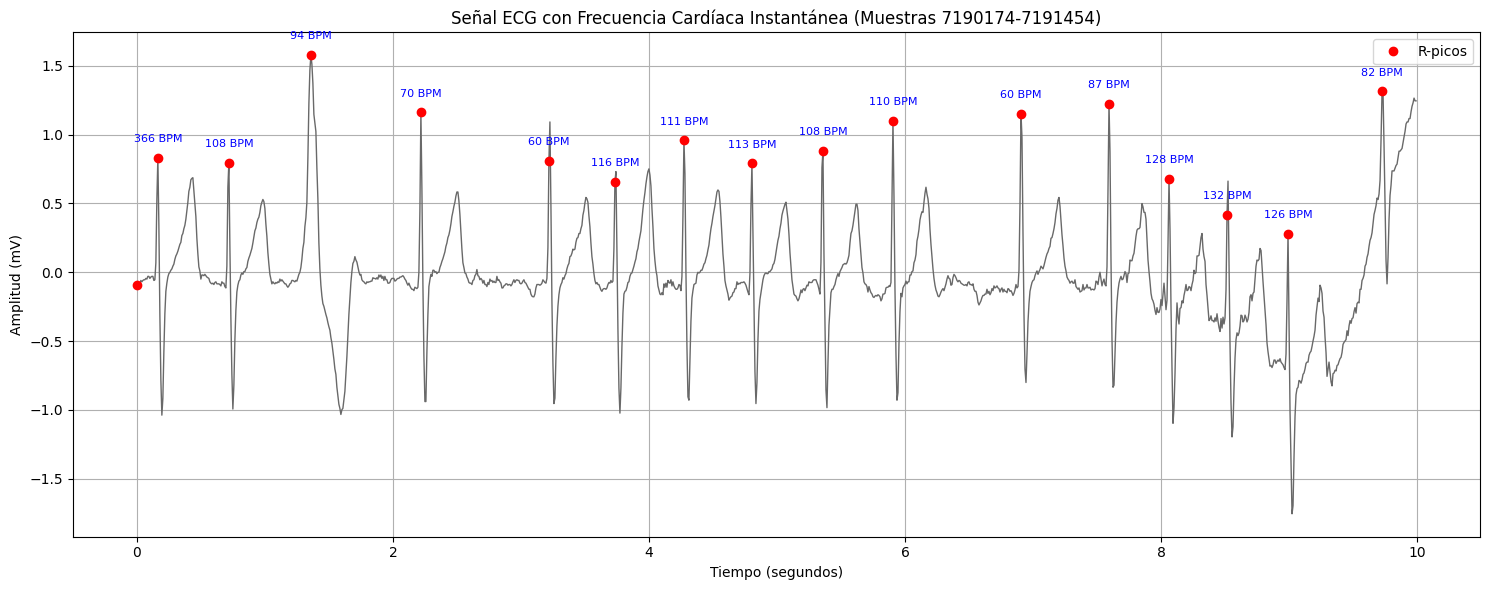

In [146]:
plt.figure(figsize=(15, 6))


plt.plot(time_axis_segment, ecg_signal_segment, color='dimgray', linewidth=1)

# Graficamos marcadores de picos R
# Se cambian a que sean relativos conforme a la Fs
r_peak_times_segment = r_peak_locations_segment / plot_fs

valid_r_peak_indices = r_peak_locations_segment[r_peak_locations_segment < len(ecg_signal_segment)]
r_peak_values_segment = ecg_signal_segment[valid_r_peak_indices]
plt.plot(r_peak_times_segment[:len(valid_r_peak_indices)], r_peak_values_segment, 'ro', markersize=6, label='R-picos')

# Agregamos etiquetas en los picos
if len(instantaneous_hr_bpm) > 0 and len(r_peak_times_segment) > 1:
    for i in range(len(instantaneous_hr_bpm)):

        hr_x_time = r_peak_times_segment[i + 1]
        hr_y_value = ecg_signal_segment[r_peak_locations_segment[i+1]] + 0.1

        plt.text(hr_x_time, hr_y_value,
                 f'{instantaneous_hr_bpm[i]:.0f} BPM',
                 fontsize=8, color='blue', ha='center', va='bottom')

plt.title(f'Señal ECG con Frecuencia Cardíaca Instantánea (Muestras {plot_start_sample}-{plot_end_sample})')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud (mV)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [147]:
# Detección de Arritmias

arrhythmias_segment = []

for bpm in instantaneous_hr_bpm:
    if bpm < 60:
        arrhythmias_segment.append("Bradicardia")
    elif bpm > 100:
        arrhythmias_segment.append("Taquicardia")
    else:
        arrhythmias_segment.append("Normal")

# Dataframe con los resultados
df_segment_arrhythmias = pd.DataFrame({
    "Instantaneous BPM": instantaneous_hr_bpm,
    "Clasificación": arrhythmias_segment
})

print("\nClasificación de arritmias para el segmento de ECG:")
print("--------------------------------------------------")
print(df_segment_arrhythmias)

summary_segment = df_segment_arrhythmias["Clasificación"].value_counts()

print("\nResumen de arritmias en el segmento:")
print(summary_segment)


Clasificación de arritmias para el segmento de ECG:
--------------------------------------------------
    Instantaneous BPM Clasificación
0          365.714286   Taquicardia
1          108.169014   Taquicardia
2           93.658537        Normal
3           69.818182        Normal
4           60.000000        Normal
5          116.363636   Taquicardia
6          111.304348   Taquicardia
7          112.941176   Taquicardia
8          108.169014   Taquicardia
9          109.714286   Taquicardia
10          60.000000        Normal
11          87.272727        Normal
12         128.000000   Taquicardia
13         132.413793   Taquicardia
14         125.901639   Taquicardia
15          81.702128        Normal

Resumen de arritmias en el segmento:
Clasificación
Taquicardia    10
Normal          6
Name: count, dtype: int64


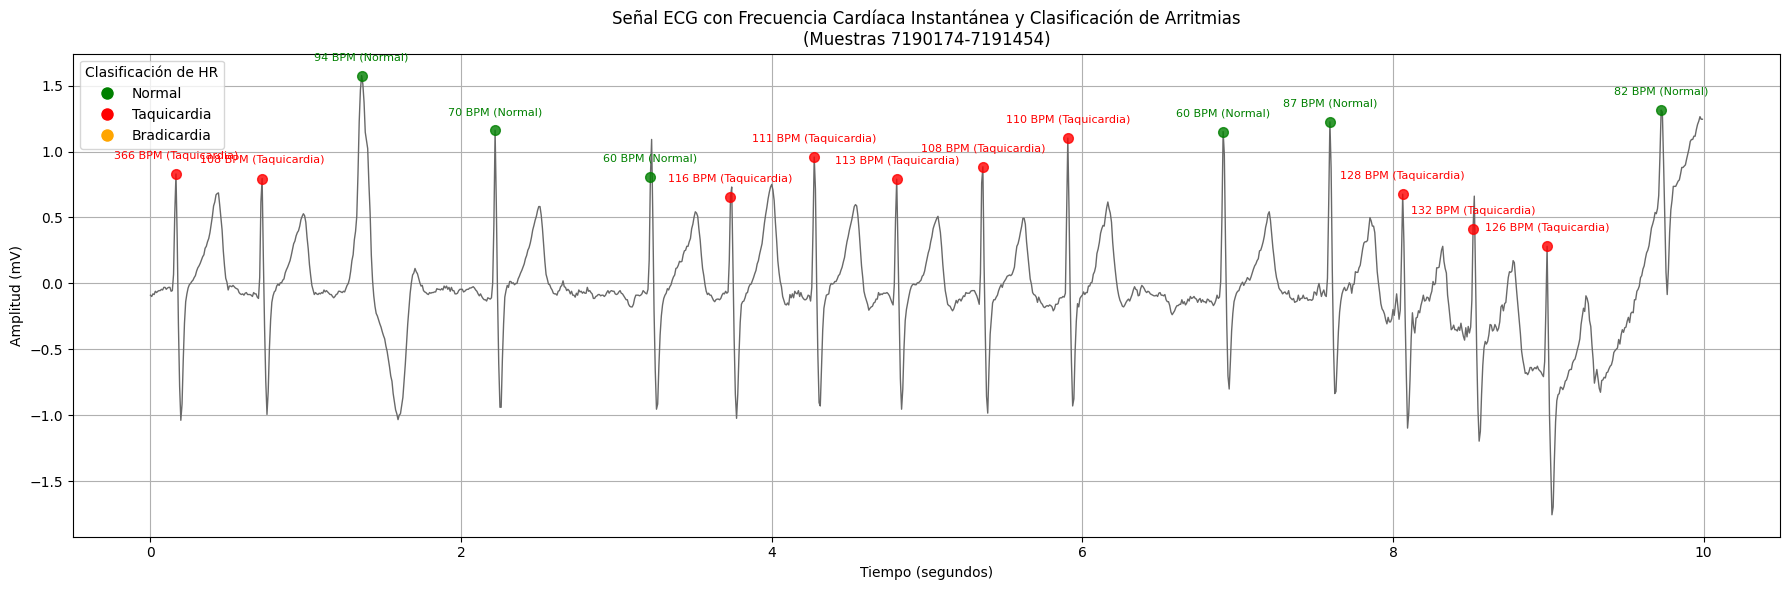

In [148]:
# Defimos colores de la clasificación
color_map = {
    "Bradicardia": "orange",
    "Normal": "green",
    "Taquicardia": "red"
}

plt.figure(figsize=(18, 6))


plt.plot(time_axis_segment, ecg_signal_segment, color='dimgray', linewidth=1)


r_peak_times_segment = r_peak_locations_segment / plot_fs

valid_r_peak_indices = r_peak_locations_segment[r_peak_locations_segment < len(ecg_signal_segment)]
r_peak_values_segment = ecg_signal_segment[valid_r_peak_indices]


if len(instantaneous_hr_bpm) > 0 and len(r_peak_times_segment) > 1:
    for i in range(len(instantaneous_hr_bpm)):
        classification = df_segment_arrhythmias['Clasificación'].iloc[i]
        hr_color = color_map.get(classification, 'black')

        hr_x_time = r_peak_times_segment[i + 1]
        hr_y_value_signal = ecg_signal_segment[r_peak_locations_segment[i+1]]
        hr_y_value_text = hr_y_value_signal + 0.1

        plt.plot(hr_x_time, hr_y_value_signal, 'o', color=hr_color, markersize=7, alpha=0.8)

        plt.text(hr_x_time, hr_y_value_text,
                 f'{instantaneous_hr_bpm[i]:.0f} BPM ({classification})',
                 fontsize=8, color=hr_color, ha='center', va='bottom')

plt.title(f'Señal ECG con Frecuencia Cardíaca Instantánea y Clasificación de Arritmias\n(Muestras {plot_start_sample}-{plot_end_sample})')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud (mV)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Normal', markerfacecolor='green', markersize=10),
                     plt.Line2D([0], [0], marker='o', color='w', label='Taquicardia', markerfacecolor='red', markersize=10),
                     plt.Line2D([0], [0], marker='o', color='w', label='Bradicardia', markerfacecolor='orange', markersize=10)],
           title='Clasificación de HR')
plt.tight_layout()
plt.show()

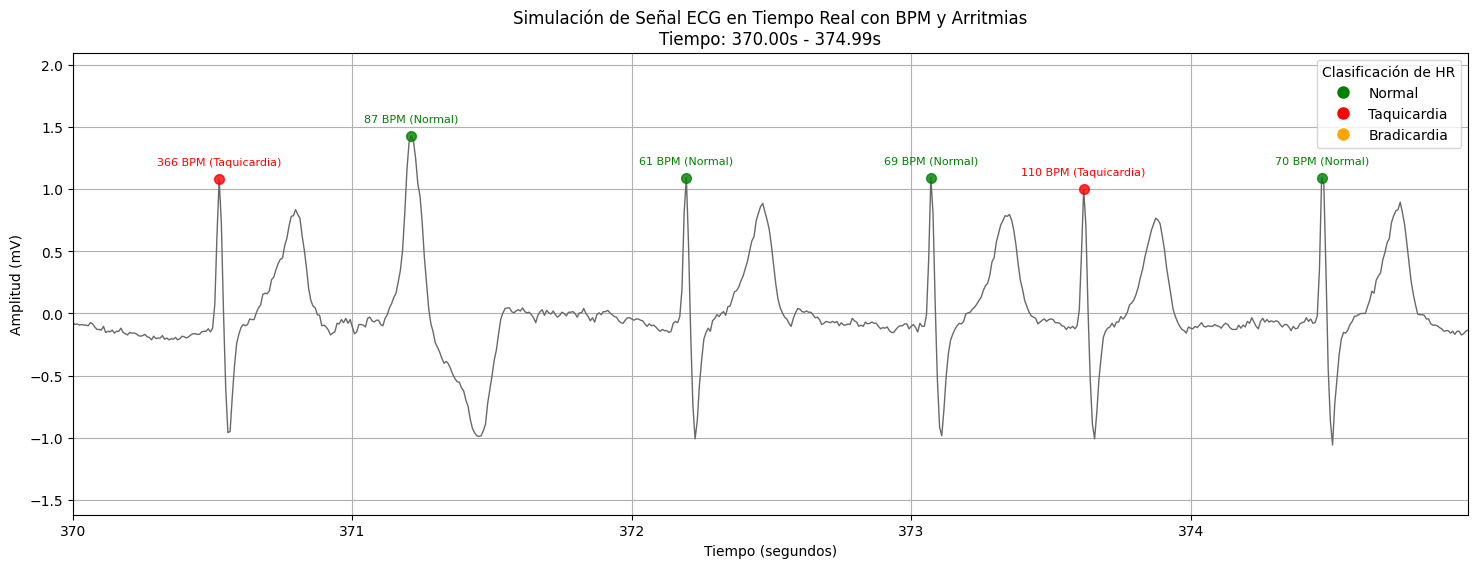


Simulación detenida por el usuario.
Fin de la simulación.


In [149]:
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import display, clear_output
import pandas as pd
import wfdb

# --- Configuration (reusing global variables where appropriate) ---
fs = record.fs # Sampling frequency from previous cells
full_signal = signal # The full ECG signal from previous cells
# Assuming 'ann' (full annotations) and 'record_path' are available globally

# Define parameters for the simulated real-time stream
segment_seconds = 5 # Duration of each 'real-time' plotted segment in seconds
samples_per_segment = int(segment_seconds * fs)

# Define colors for arrhythmia classifications (re-defining for cell independence)
color_map = {
    "Bradicardia": "orange",
    "Normal": "green",
    "Taquicardia": "red"
}

# --- Set up the interactive plot ---
plt.ion() # Turn on interactive mode for live updates
fig, ax = plt.subplots(figsize=(18, 6))

ax.set_title('Simulación de Señal ECG en Tiempo Real con BPM y Arritmias')
ax.set_xlabel('Tiempo (segundos)')
ax.set_ylabel('Amplitud (mV)')
ax.grid(True)
# Add initial legend for clarity
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label='Normal', markerfacecolor='green', markersize=10),
                  plt.Line2D([0], [0], marker='o', color='w', label='Taquicardia', markerfacecolor='red', markersize=10),
                  plt.Line2D([0], [0], marker='o', color='w', label='Bradicardia', markerfacecolor='orange', markersize=10)]
ax.legend(handles=legend_handles, title='Clasificación de HR', loc='upper right')

# Set fixed y-limits for consistent visualization
# Using min/max of a representative portion of the signal for min/max estimation
min_val = np.min(full_signal[0:min(len(full_signal), fs * 60)]) # First minute of data for min/max estimation
max_val = np.max(full_signal[0:min(len(full_signal), fs * 60)])
ax.set_ylim(min_val - 0.2, max_val + 0.5) # Adjust slightly for labels

# --- Simulate real-time streaming ---
current_start_sample = 0
total_signal_length = len(full_signal)
plot_update_interval_seconds = 0.5 # How fast the plot updates (not actual data duration)

print("Iniciando simulación de ECG en tiempo real. Presiona 'Interrumpir ejecución' para detener.")

try:
    while current_start_sample < total_signal_length:
        current_end_sample = min(current_start_sample + samples_per_segment, total_signal_length)

        # Ensure there's enough data for a segment
        if current_end_sample - current_start_sample < samples_per_segment and current_start_sample != 0:
            break # Not enough data for a full segment, stop (unless it's the very first segment)

        # Get the current ECG signal segment
        ecg_segment = full_signal[current_start_sample:current_end_sample]
        # Absolute time for x-axis of the current segment
        time_segment = np.arange(len(ecg_segment)) / fs + (current_start_sample / fs)

        # Load annotations for the current segment, shifting samples to be relative to segment start
        ann_seg = wfdb.rdann(record_path, 'atr', sampfrom=current_start_sample, sampto=current_end_sample, shift_samps=True)
        r_peak_locations_segment = ann_seg.sample # These are relative to current_start_sample

        # Process R-peaks and calculate instantaneous HR
        instantaneous_hr_bpm = np.array([])
        arrhythmias_segment = []

        if len(r_peak_locations_segment) >= 2: # Need at least two R-peaks to calculate RR interval
            rr_intervals_segment_samples = np.diff(r_peak_locations_segment)
            # Ensure rr_intervals are positive and non-zero
            rr_intervals_segment_samples = rr_intervals_segment_samples[rr_intervals_segment_samples > 0]

            if len(rr_intervals_segment_samples) > 0:
                instantaneous_hr_bpm = 60 * fs / rr_intervals_segment_samples

                # Classify arrhythmias
                for bpm_val in instantaneous_hr_bpm:
                    if bpm_val < 60:
                        arrhythmias_segment.append("Bradicardia")
                    elif bpm_val > 100:
                        arrhythmias_segment.append("Taquicardia")
                    else:
                        arrhythmias_segment.append("Normal")
            else:
                instantaneous_hr_bpm = np.array([]) # No valid RR intervals
                arrhythmias_segment = []

        # --- Update the plot ---
        ax.clear() # Clear previous plot content
        ax.plot(time_segment, ecg_segment, color='dimgray', linewidth=1)

        # Plot R-peak markers and labels with color-coding
        # We plot from the second R-peak as instantaneous_hr_bpm is calculated from RR intervals
        if len(instantaneous_hr_bpm) > 0 and len(r_peak_locations_segment) >= 2:
            # R-peak times for plotting are absolute times of the *second* R-peak in each interval
            r_peak_times_for_plotting = (r_peak_locations_segment[1:] / fs) + (current_start_sample / fs)
            # R-peak values are from the ecg_segment at the relative R-peak locations
            r_peak_values_for_plotting = ecg_segment[r_peak_locations_segment[1:]]

            for i in range(len(instantaneous_hr_bpm)):
                if i < len(arrhythmias_segment): # Ensure classification exists
                    classification = arrhythmias_segment[i]
                    hr_color = color_map.get(classification, 'black')

                    # x-coordinate: absolute time of the second R-peak in the interval
                    hr_x_time = r_peak_times_for_plotting[i]
                    # y-coordinate: value of the second R-peak
                    hr_y_value_signal = r_peak_values_for_plotting[i]
                    # Offset for the text label
                    hr_y_value_text = hr_y_value_signal + 0.1 # Small offset above the peak

                    # Plot R-peak marker
                    ax.plot(hr_x_time, hr_y_value_signal, 'o', color=hr_color, markersize=7, alpha=0.8)

                    # Add instantaneous HR label
                    ax.text(hr_x_time, hr_y_value_text,
                            f'{instantaneous_hr_bpm[i]:.0f} BPM ({classification})',
                            fontsize=8, color=hr_color, ha='center', va='bottom')

        ax.set_title(f'Simulación de Señal ECG en Tiempo Real con BPM y Arritmias\n' +
                     f'Tiempo: {time_segment[0]:.2f}s - {time_segment[-1]:.2f}s')
        ax.set_xlabel('Tiempo (segundos)')
        ax.set_ylabel('Amplitud (mV)')
        ax.grid(True)
        ax.set_xlim(time_segment[0], time_segment[-1]) # Adjust x-limits to current segment
        ax.set_ylim(min_val - 0.2, max_val + 0.5) # Maintain fixed y-limits for consistency
        ax.legend(handles=legend_handles, title='Clasificación de HR', loc='upper right')

        # Update and display the plot
        clear_output(wait=True)
        display(fig)

        # Advance to the next segment
        current_start_sample += samples_per_segment
        time.sleep(plot_update_interval_seconds) # Pause for a moment to simulate real-time

except KeyboardInterrupt:
    print("\nSimulación detenida por el usuario.")
finally:
    plt.ioff() # Turn off interactive mode
    plt.close(fig) # Close the figure
    print("Fin de la simulación.")